In [93]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt
from palmerpenguins import load_penguins
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_style("whitegrid")

In [2]:
data = load_penguins()
data.dropna(inplace=True)

In [3]:
data.info()

<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    str    
 1   island             333 non-null    str    
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    str    
 7   year               333 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 23.4 KB


In [4]:
# Proper data conversion

data[['sex', 'species', 'island']] = data[['sex', 'species', 'island']].astype('category')
data.info()


<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   species            333 non-null    category
 1   island             333 non-null    category
 2   bill_length_mm     333 non-null    float64 
 3   bill_depth_mm      333 non-null    float64 
 4   flipper_length_mm  333 non-null    float64 
 5   body_mass_g        333 non-null    float64 
 6   sex                333 non-null    category
 7   year               333 non-null    int64   
dtypes: category(3), float64(4), int64(1)
memory usage: 16.6 KB


# Visual examination

## Pairplot

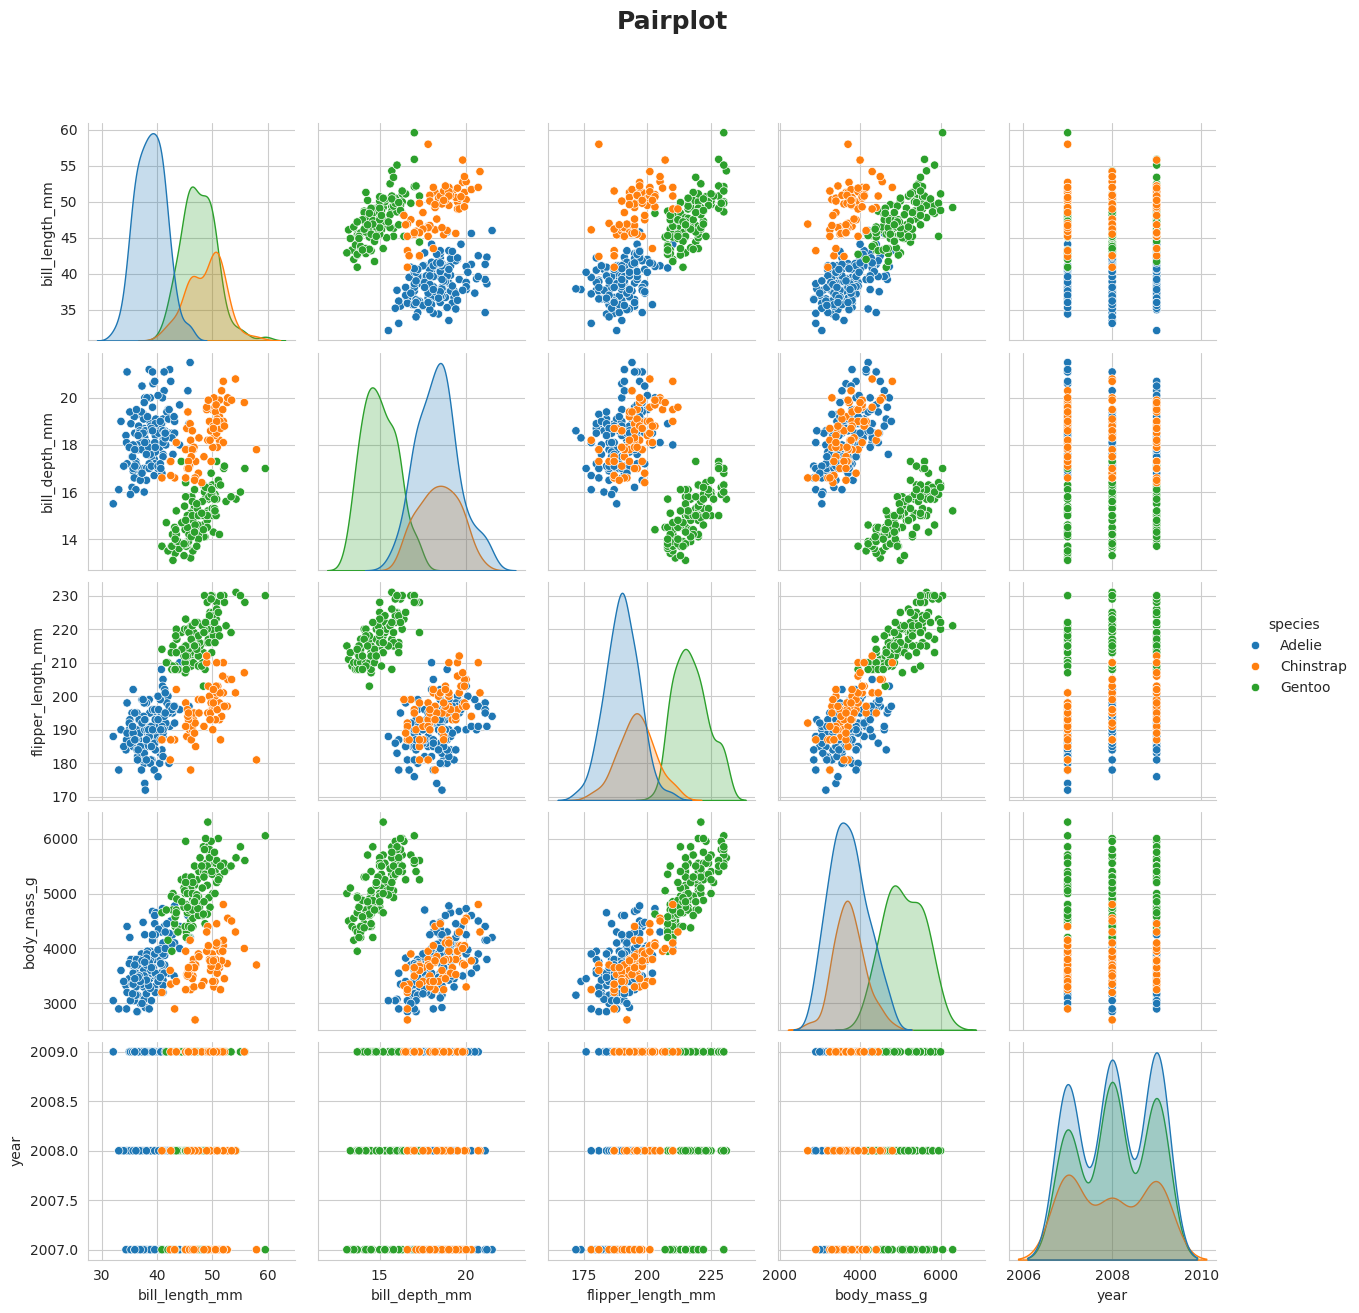

In [5]:
g = sns.pairplot(data, hue='species')
g.figure.suptitle('Pairplot', fontsize=18, fontweight='bold', y=1.05)
g.tight_layout()
plt.show()

## Correlations

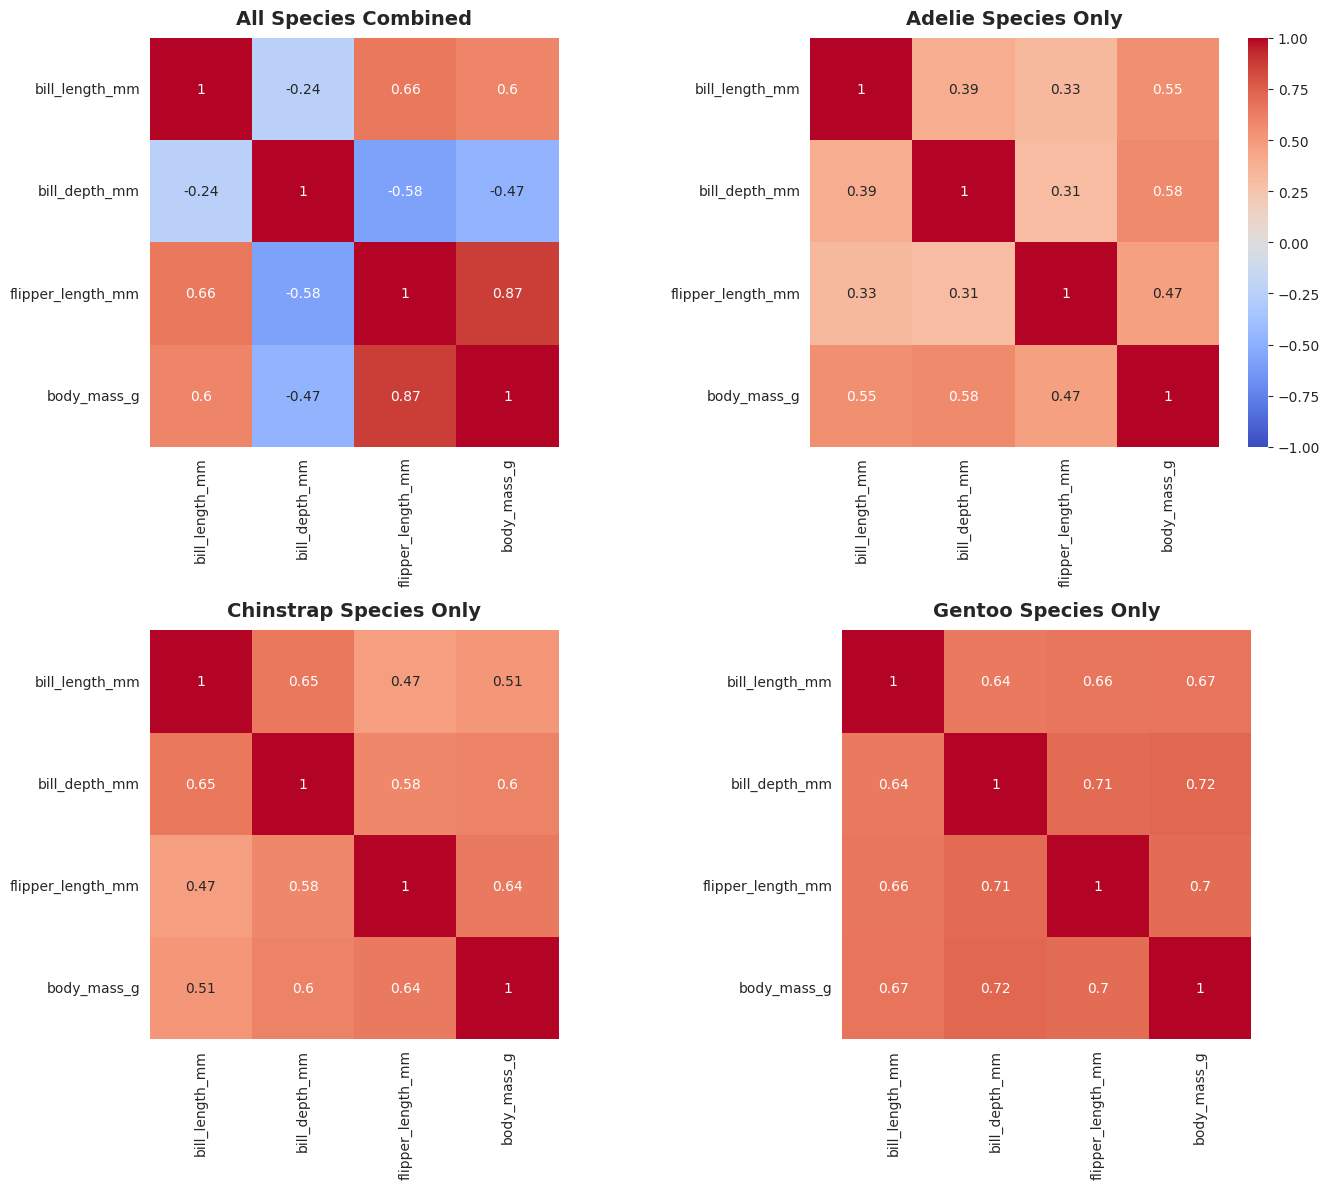

In [6]:
# 1. Load data and filter for numeric columns
df = sns.load_dataset("penguins")
features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

# 2. Set up the 2x2 figure grid (Standard figure-based layout)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
axes = axes.flatten()  # Flatten to make indexing 0, 1, 2, 3 easier

# Define our 4 plotting scenarios
scenarios = [
    {"title": "All Species Combined", "data": df},
    {"title": "Adelie Species Only", "data": df[df["species"] == "Adelie"]},
    {"title": "Chinstrap Species Only", "data": df[df["species"] == "Chinstrap"]},
    {"title": "Gentoo Species Only", "data": df[df["species"] == "Gentoo"]},
]

# 3. Loop through scenarios and plot heatmaps
for i, scenario in enumerate(scenarios):
    # Compute correlation matrix for the numeric features
    corr_matrix = scenario["data"][features].corr()

    # Plot using axes-level sns.heatmap on the specific grid spot
    sns.heatmap(
        corr_matrix,
        ax=axes[i],
        annot=True,  # Shows the correlation numbers
        cmap="coolwarm",  # Good divergence palette for correlations
        vmin=-1,
        vmax=1,  # Forces same color scale for comparison
        square=True,  # Keeps the subplots perfectly square
        cbar=True if i == 1 else False,  # Keeps layout clean by showing only 1 colorbar
    )

    axes[i].set_title(scenario["title"], fontsize=14, fontweight="bold", pad=10)

# 4. Final layout polish
plt.tight_layout()
plt.show()


The correlation results change significantly when analyzed with all the three species combined versus when analyzed each species independently. This is called the Simpson's paradox and requires the inclusion of the categorical variable defining the groups. In this case, the categorical variable is the species.

## Linear Plot

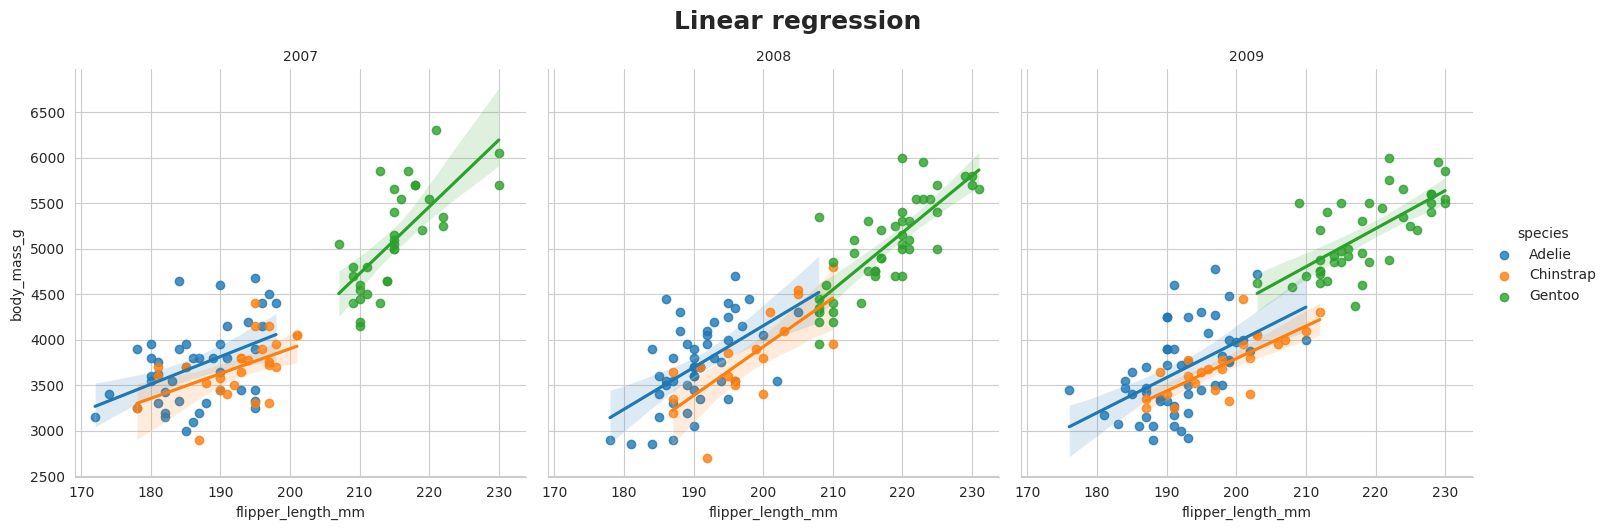

In [7]:
g = sns.lmplot(data, x='flipper_length_mm', y='body_mass_g', hue='species', col='year', col_wrap=3)
g.set_titles('{col_name}')
g.fig.suptitle('Linear regression', fontsize=18, fontweight='bold', y=1.05)
plt.show()

# Linear Regression

## Inferential workflow

### 1. Training and testing split

In [8]:
X = data.drop('body_mass_g', axis=1)
y = data['body_mass_g']
train, test =train_test_split(data, test_size=0.2, random_state=42)

In [9]:
print(f'Training set: {train.shape} and testing set {test.shape} ')

Training set: (266, 8) and testing set (67, 8) 


The train/test split done at this point is for EDA purposes

### 2. Exploratory Data Analysis (EDA)

Year variable: numeric or categorical?

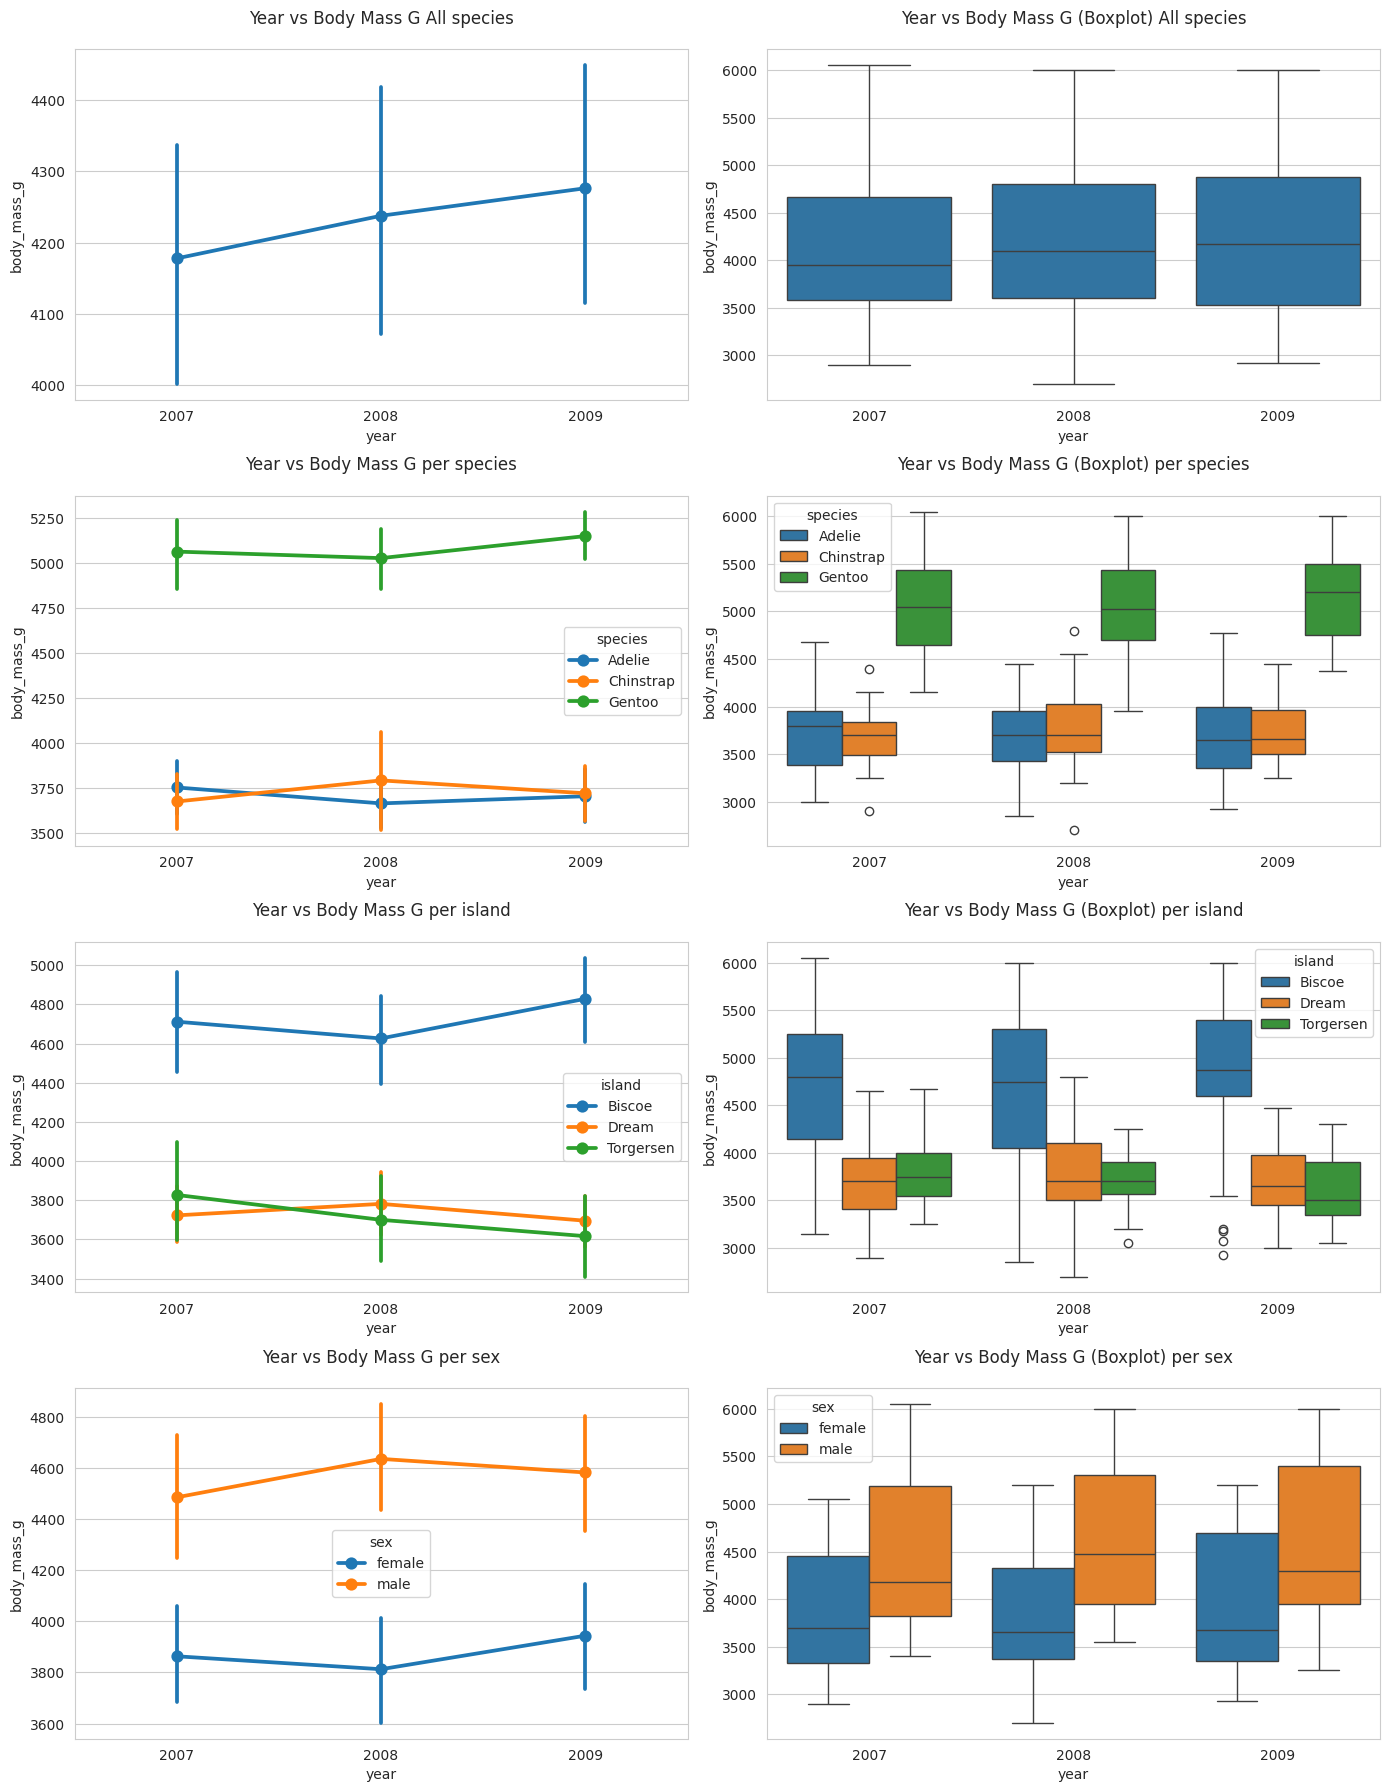

In [15]:
figure, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 18))
axes = axes.flatten()
sns.pointplot(data=train, x='year', y='body_mass_g', ax=axes[0])
axes[0].set_title('Year vs Body Mass G All species', y=1.05)
sns.boxplot(data=train, x='year', y='body_mass_g', ax=axes[1])
axes[1].set_title('Year vs Body Mass G (Boxplot) All species', y=1.05)

sns.pointplot(data=train, x='year', y='body_mass_g', ax=axes[2], hue='species')
axes[2].set_title('Year vs Body Mass G per species', y=1.05)
sns.boxplot(data=train, x='year', y='body_mass_g', ax=axes[3], hue='species')
axes[3].set_title('Year vs Body Mass G (Boxplot) per species', y=1.05)

sns.pointplot(data=train, x='year', y='body_mass_g', ax=axes[4], hue='island')
axes[4].set_title('Year vs Body Mass G per island', y=1.05)
sns.boxplot(data=train, x='year', y='body_mass_g', ax=axes[5], hue='island')
axes[5].set_title('Year vs Body Mass G (Boxplot) per island', y=1.05)

sns.pointplot(data=train, x='year', y='body_mass_g', ax=axes[6], hue='sex')
axes[6].set_title('Year vs Body Mass G per sex', y=1.05)
sns.boxplot(data=train, x='year', y='body_mass_g', ax=axes[7], hue='sex')
axes[7].set_title('Year vs Body Mass G (Boxplot) per sex', y=1.05)

plt.tight_layout()
plt.show()

There is a trend through the years so 'year' will remain as a numerical variable

Correlations from Species perspective

In [16]:
features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", 'year']

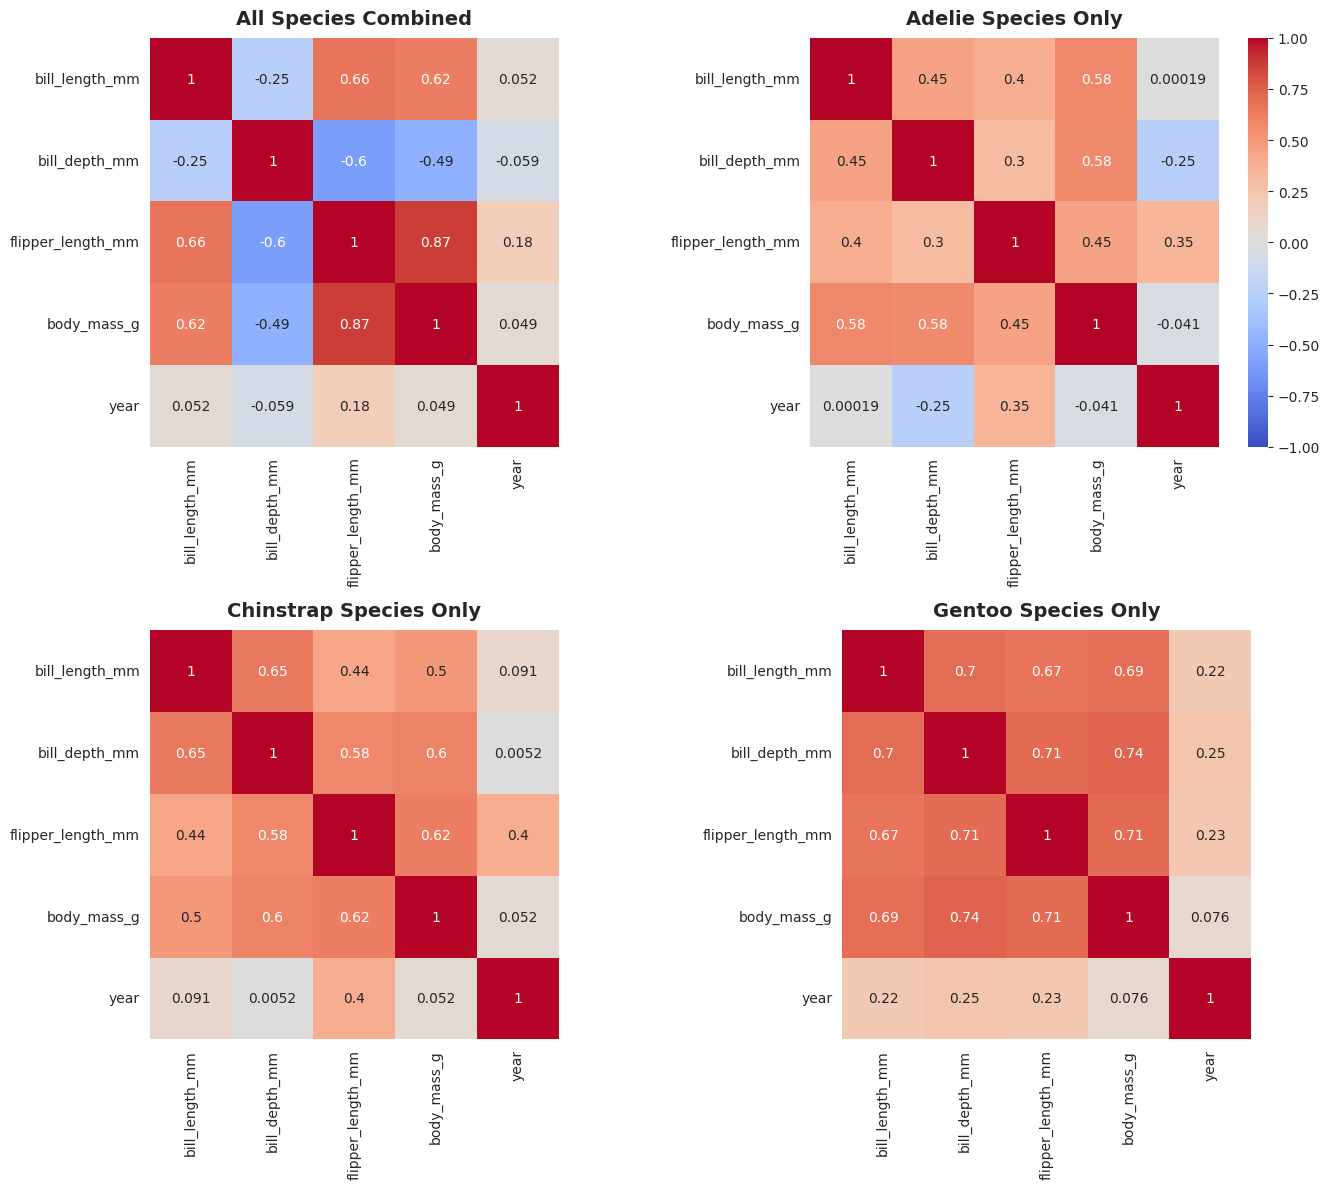

In [17]:
# 1. Load data and filter for numeric columns
df = train

# 2. Set up the 2x2 figure grid (Standard figure-based layout)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
axes = axes.flatten()  # Flatten to make indexing 0, 1, 2, 3 easier

# Define our 4 plotting scenarios
scenarios = [
    {"title": "All Species Combined", "data": df},
    {"title": "Adelie Species Only", "data": df[df["species"] == "Adelie"]},
    {"title": "Chinstrap Species Only", "data": df[df["species"] == "Chinstrap"]},
    {"title": "Gentoo Species Only", "data": df[df["species"] == "Gentoo"]},
]

# 3. Loop through scenarios and plot heatmaps
for i, scenario in enumerate(scenarios):
    # Compute correlation matrix for the numeric features
    corr_matrix = scenario["data"][features].corr()

    # Plot using axes-level sns.heatmap on the specific grid spot
    sns.heatmap(
        corr_matrix,
        ax=axes[i],
        annot=True,  # Shows the correlation numbers
        cmap="coolwarm",  # Good divergence palette for correlations
        vmin=-1,
        vmax=1,  # Forces same color scale for comparison
        square=True,  # Keeps the subplots perfectly square
        cbar=True if i == 1 else False,  # Keeps layout clean by showing only 1 colorbar
    )

    axes[i].set_title(scenario["title"], fontsize=14, fontweight="bold", pad=10)

# 4. Final layout polish
plt.tight_layout()
plt.show()


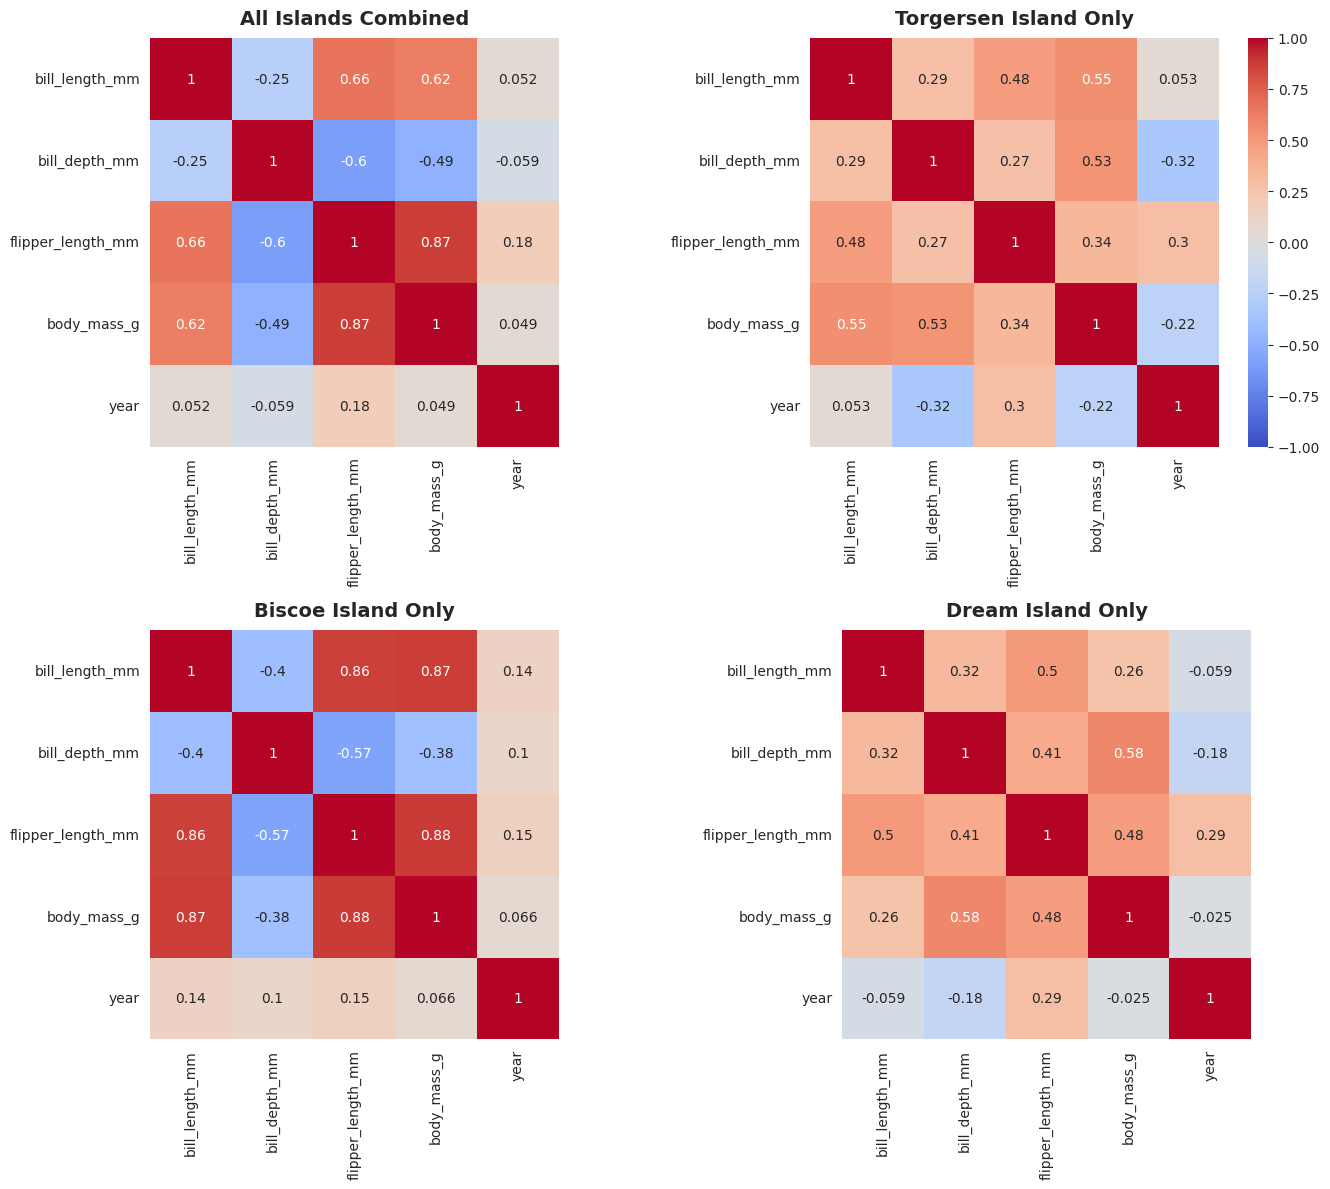

In [18]:
# 1. Load data and filter for numeric columns
df = train
features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", 'year']

# 2. Set up the 2x2 figure grid (Standard figure-based layout)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
axes = axes.flatten()  # Flatten to make indexing 0, 1, 2, 3 easier

# Define our 4 plotting scenarios
scenarios = [
    {"title": "All Islands Combined", "data": df},
    {"title": "Torgersen Island Only", "data": df[df["island"] == "Torgersen"]},
    {"title": "Biscoe Island Only", "data": df[df["island"] == "Biscoe"]},
    {"title": "Dream Island Only", "data": df[df["island"] == "Dream"]}
]

# 3. Loop through scenarios and plot heatmaps
for i, scenario in enumerate(scenarios):
    # Compute correlation matrix for the numeric features
    corr_matrix = scenario["data"][features].corr()

    # Plot using axes-level sns.heatmap on the specific grid spot
    sns.heatmap(
        corr_matrix,
        ax=axes[i],
        annot=True,  # Shows the correlation numbers
        cmap="coolwarm",  # Good divergence palette for correlations
        vmin=-1,
        vmax=1,  # Forces same color scale for comparison
        square=True,  # Keeps the subplots perfectly square
        cbar=True if i == 1 else False,  # Keeps layout clean by showing only 1 colorbar
    )

    axes[i].set_title(scenario["title"], fontsize=14, fontweight="bold", pad=10)

# 4. Final layout polish
plt.tight_layout()
plt.show()


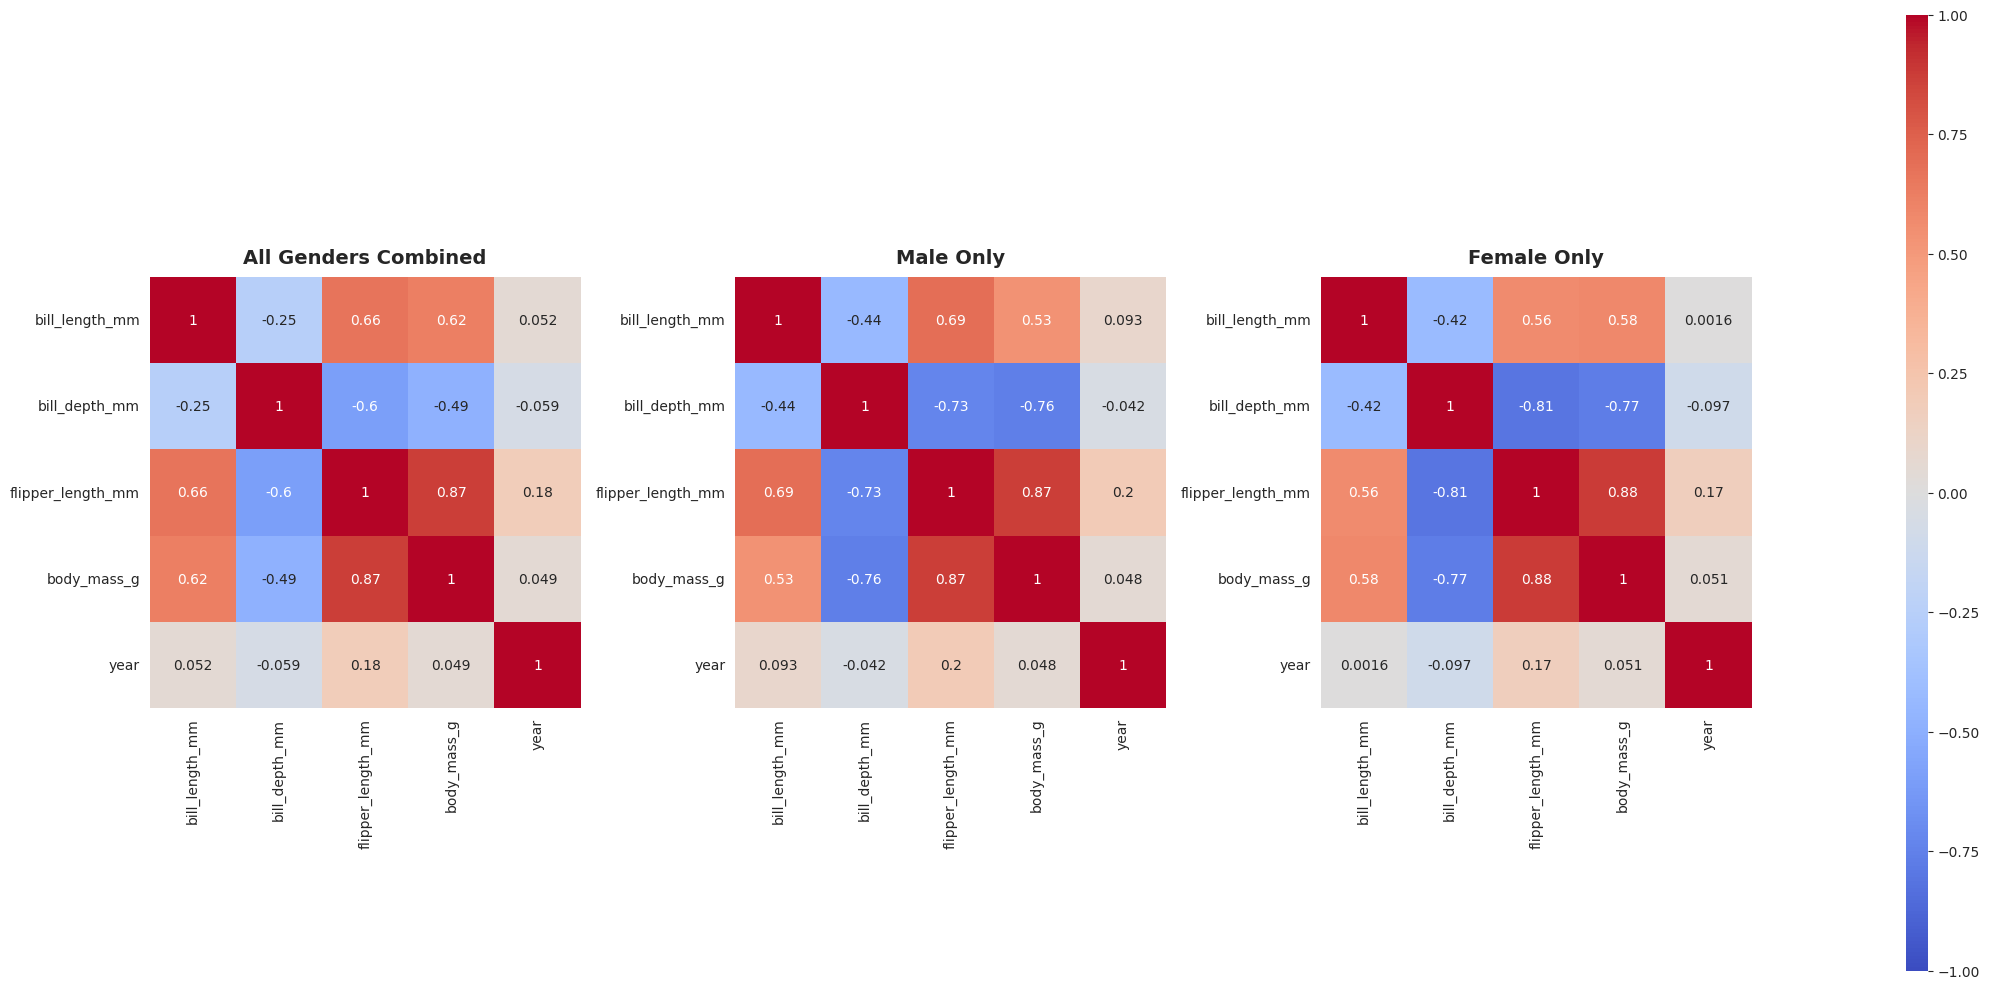

In [19]:
# 1. Load data and filter for numeric columns
df = train
features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", 'year']

# 2. Set up the figure grid with an extra column for the colorbar
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 10), gridspec_kw={'width_ratios': [1, 1, 1, 0.05]})
cbar_ax = axes[-1]  # The last axis will be used for the colorbar

# Define our 3 plotting scenarios
scenarios = [
    {"title": "All Genders Combined", "data": df},
    {"title": "Male Only", "data": df[df["sex"] == "male"]},
    {"title": "Female Only", "data": df[df["sex"] == "female"]}
]

# 3. Loop through scenarios and plot heatmaps
for i, scenario in enumerate(scenarios):
    # Compute correlation matrix for the numeric features
    corr_matrix = scenario["data"][features].corr()

    # Plot using axes-level sns.heatmap on the specific grid spot
    sns.heatmap(
        corr_matrix,
        ax=axes[i],
        annot=True,  # Shows the correlation numbers
        cmap="coolwarm",  # Good divergence palette for correlations
        vmin=-1,
        vmax=1,  # Forces same color scale for comparison
        square=True,  # Keeps the subplots perfectly square
        cbar=True if i == 2 else False,  # Show colorbar only on the last heatmap
        cbar_ax=cbar_ax if i == 2 else None,  # Assign the colorbar to the dedicated axis
    )

    axes[i].set_title(scenario["title"], fontsize=14, fontweight="bold", pad=10)

# 4. Final layout polish
plt.tight_layout()
plt.show()


For the next steps, the data must be splitted into X_train, X_test, y_train and y_test

### 3. One-Hot Encoding

In [74]:
X = data.drop(columns=["body_mass_g"])
y = data['body_mass_g']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [81]:
categorical_cols = ['species', 'island', 'sex']
numerical_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'year']

categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer(transformers=[('cat', categorical_transformer, categorical_cols), ('num', 'passthrough', numerical_cols)])
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
X_train_final = pd.DataFrame(X_train_encoded, columns=feature_names, index=X_train.index)
X_test_final = pd.DataFrame(X_test_encoded, columns=feature_names, index=X_test.index)


,cat__species_Chinstrap,cat__species_Gentoo,cat__island_Dream,cat__island_Torgersen,cat__sex_male,num__bill_length_mm,num__bill_depth_mm,num__flipper_length_mm,num__year
232,0.0,1.0,0.0,0.0,0.0,49.1,14.5,212.0,2009.0
84,0.0,0.0,1.0,0.0,0.0,37.3,17.8,191.0,2008.0
306,1.0,0.0,1.0,0.0,0.0,40.9,16.6,187.0,2008.0
22,0.0,0.0,0.0,0.0,0.0,35.9,19.2,189.0,2007.0
29,0.0,0.0,0.0,0.0,1.0,40.5,18.9,180.0,2007.0


### 4. VIF Calulation

In [82]:
def iteratively_drop_high_vif(X, threshold=5.0):
    """
    Iteratively drops features from a dataframe based on the highest VIF.

    Parameters:
    X : pandas DataFrame (Your encoded X_train)
    threshold : float, the VIF cutoff point (usually 5.0 or 10.0)

    Returns:
    pandas DataFrame with high VIF features removed.
    """
    # Create a copy to avoid modifying the original dataframe in place
    X_vif = X.copy()

    dropped_features = []

    while True:
        # 1. Add the constant column required by statsmodels
        X_with_const = sm.add_constant(X_vif)

        # 2. Calculate VIF for each feature
        vif_data = pd.DataFrame()
        vif_data["Feature"] = X_with_const.columns
        vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i)
                           for i in range(X_with_const.shape[1])]

        # 3. We ignore the 'const' row for our dropping logic
        vif_data = vif_data[vif_data["Feature"] != "const"]

        # 4. Find the maximum VIF
        max_vif_row = vif_data.loc[vif_data["VIF"].idxmax()]
        max_vif_value = max_vif_row["VIF"]
        max_vif_feature = max_vif_row["Feature"]

        # 5. Check against threshold
        if max_vif_value > threshold:
            print(f"Dropping '{max_vif_feature}' with VIF: {max_vif_value:.2f}")
            X_vif = X_vif.drop(columns=[max_vif_feature])
            dropped_features.append(max_vif_feature)
        else:
            break

    print("\n--- Final VIF Scores ---")
    print(vif_data.sort_values(by="VIF", ascending=False).to_string(index=False))

    return X_vif, dropped_features

# Execute the function on your newly encoded training data
X_train_stable, dropped_cols = iteratively_drop_high_vif(X_train_final, threshold=5.0)

# IMPORTANT: You must drop these EXACT same columns from X_test to keep the shapes aligned
if dropped_cols:
    X_test_stable = X_test_final.drop(columns=dropped_cols)
else:
    X_test_stable = X_test_final.copy()

Dropping 'cat__species_Gentoo' with VIF: 20.32
Dropping 'num__bill_length_mm' with VIF: 5.26

--- Final VIF Scores ---
               Feature      VIF
    num__bill_depth_mm 3.620441
num__flipper_length_mm 2.979692
     cat__island_Dream 2.807676
         cat__sex_male 2.043634
cat__species_Chinstrap 1.766208
 cat__island_Torgersen 1.609104
             num__year 1.058721


### 5. Scaling / Standarization

In [87]:
# 1. Initialize the scaler
scaler = StandardScaler()

# 2. Fit and transform on the training data ONLY
# We use X_train_stable which has the high-VIF columns already removed
X_train_scaled_array = scaler.fit_transform(X_train_stable)

# 3. Transform the test data blindly
X_test_scaled_array = scaler.transform(X_test_stable)

# 4. Convert back to Pandas DataFrames to retain column names for the OLS summary
X_train_scaled = pd.DataFrame(
    X_train_scaled_array,
    columns=X_train_stable.columns,
    index=X_train_stable.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled_array,
    columns=X_test_stable.columns,
    index=X_test_stable.index
)

### 6. Fitting into OLS Model

In [89]:
# 1. Add the constant (intercept) to the scaled training data
# Even though the features are scaled, y_train is not mean-centered,
# so the model still needs an intercept to calculate predictions correctly.
X_train_final_with_const = sm.add_constant(X_train_scaled)

# 2. Define the OLS model
# Note the syntax for statsmodels: target (y) comes first, then features (X)
ols_model = sm.OLS(y_train, X_train_final_with_const)

# 3. Fit the model to calculate the coefficients
fitted_model = ols_model.fit()

# 4. Display the comprehensive statistical summary
print(fitted_model.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.843
Method:                 Least Squares   F-statistic:                     204.6
Date:                Thu, 06 Aug 2026   Prob (F-statistic):          1.96e-101
Time:                        06:43:42   Log-Likelihood:                -1908.7
No. Observations:                 266   AIC:                             3833.
Df Residuals:                     258   BIC:                             3862.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   4232

### 7. Assumptions validation

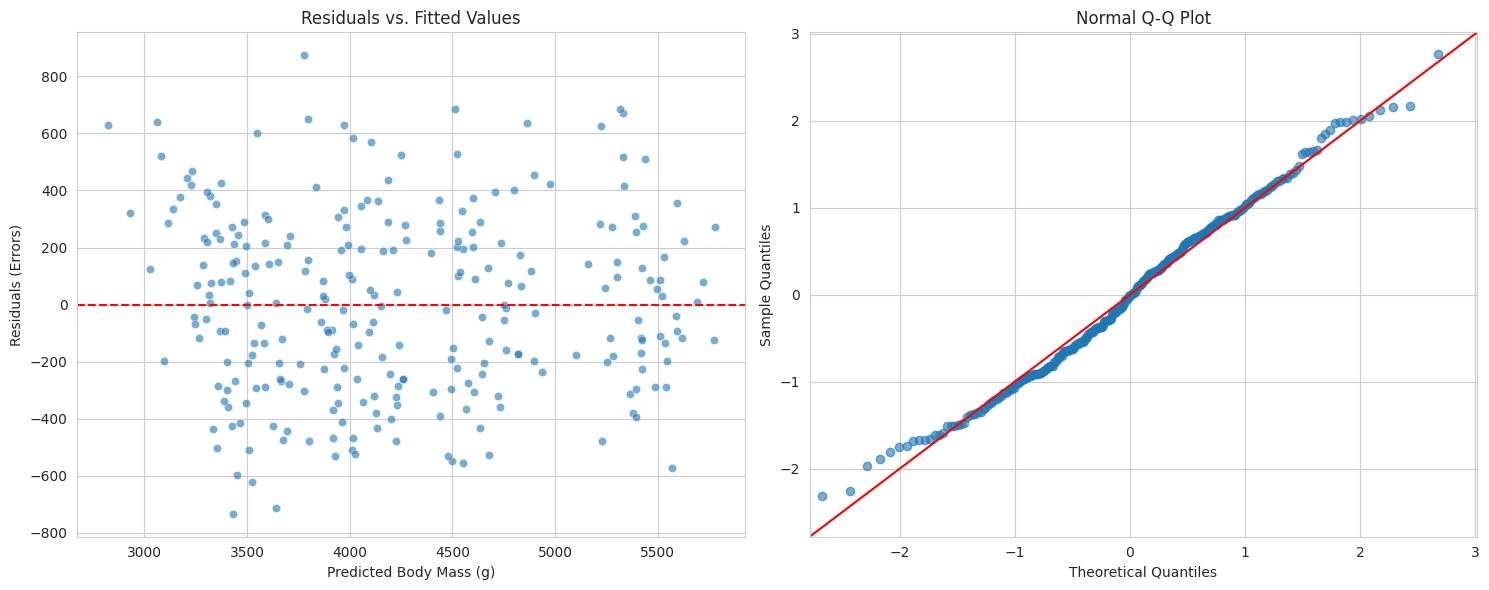

In [92]:
# 1. Extract the fitted values (predictions on X_train) and the residuals (errors)
fitted_values = fitted_model.fittedvalues
residuals = fitted_model.resid

# 2. Set up the figure for two plots
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot A: Residuals vs. Fitted Values ---
# Used to check Linearity and Homoscedasticity (constant variance)
sns.scatterplot(x=fitted_values, y=residuals, ax=ax[0], alpha=0.6)
ax[0].axhline(0, color='red', linestyle='--') # The zero-error line
ax[0].set_title('Residuals vs. Fitted Values')
ax[0].set_xlabel('Predicted Body Mass (g)')
ax[0].set_ylabel('Residuals (Errors)')

# --- Plot B: Q-Q Plot ---
# Used to check Normality of Residuals
sm.qqplot(residuals, line='45', fit=True, ax=ax[1], alpha=0.6)
ax[1].set_title('Normal Q-Q Plot')

plt.tight_layout()
plt.show()

### 8. Evaluation on the test set

In [94]:
# 1. Add the constant to your scaled TEST data
# (It must have the exact same columns as the training data used in Step 6)
X_test_final_with_const = sm.add_constant(X_test_scaled)

# 2. Generate predictions for both Train and Test
train_predictions = fitted_model.predict(X_train_final_with_const)
test_predictions = fitted_model.predict(X_test_final_with_const)

# 3. Calculate Mean Absolute Error (MAE) - easy to explain to stakeholders
train_mae = mean_absolute_error(y_train, train_predictions)
test_mae = mean_absolute_error(y_test, test_predictions)

# 4. Calculate R-squared for comparison
train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)

print(f"--- R-Squared ---")
print(f"Training R2: {train_r2:.3f}")
print(f"Testing R2:  {test_r2:.3f}")

print(f"\n--- Mean Absolute Error (Grams) ---")
print(f"Training MAE: {train_mae:.1f} g")
print(f"Testing MAE:  {test_mae:.1f} g")

--- R-Squared ---
Training R2: 0.847
Testing R2:  0.862

--- Mean Absolute Error (Grams) ---
Training MAE: 264.6 g
Testing MAE:  234.2 g


### 9. Interpretation

1. Translate the R-squared into "Confidence"
Instead of saying "The model has an R-squared of 0.85," translate what that means for their understanding of the problem.

Translation: "We are highly confident in our understanding of penguin body mass. The physical traits and categories we measured account for 85% of the total reasons why one penguin weighs more than another. Only 15% is driven by random diet, genetics, or factors we didn't measure."

2. Rank the Drivers (Using your Scaled Coefficients)
Because you standardized your features in Step 5, your coefficients act as a perfect ranking system. You can sort them by absolute value to tell stakeholders exactly what matters most.

Translation: "Flipper length is by far the strongest indicator of a penguin's weight. In fact, flipper length has roughly twice the impact on overall body mass as bill depth."

3. Explain the Categorical Surprises (The VIF Context)
This is where your work in Step 2 (EDA) and Step 4 (VIF) pays off massively. You get to explain the nuances of the data.

Translation: "You might assume that being a Gentoo penguin is the main reason for a heavier weight. However, our analysis revealed that their weight advantage is entirely explained by their larger physical frames. A Gentoo's weight is driven by its massive flippers and bill size, not merely its species label. Therefore, if you know a penguin's exact measurements, knowing its species doesn't give you any extra predictive power for its weight."

4. Provide the "Error Margin" (Using the Test Set MAE)
Stakeholders need to know how much they can trust the model in the real world. You use the Mean Absolute Error (MAE) from Step 8 to give them a margin of error.

Translation: "If we use this model in the field to estimate the weight of a new penguin based on its physical dimensions, our estimate will typically be off by about 250 grams."

The Final Deliverable
When presenting your inferential model, your final slide or report should look something like this:

Executive Summary: Drivers of Penguin Body Mass

Our analysis of the Palmer Archipelago data successfully identified the core drivers of penguin body weight. The model is highly accurate, explaining over 80% of weight variations, and generalizes perfectly to unseen data with an average error margin of just ~250g.

Key Findings:

Flipper Length is King: The primary driver of body mass is flipper length. It is the single most important metric for estimating weight in the field.

The Sex Difference: Holding all physical dimensions equal, male penguins are statistically significantly heavier than females across all islands.

Species is Redundant to Size: While Gentoo penguins are the heaviest, this is a byproduct of their physical dimensions. When controlling for flipper and bill size, the species label itself becomes statistically redundant for predicting weight.

# DRAFT

In [88]:
X_train_scaled

,cat__species_Chinstrap,cat__island_Dream,cat__island_Torgersen,cat__sex_male,num__bill_depth_mm,num__flipper_length_mm,num__year
232,-0.481125,-0.763763,-0.376339,-1.030541,-1.308932,0.743575,1.176716
84,-0.481125,1.309307,-0.376339,-1.030541,0.370128,-0.730905,-0.050760
306,2.078461,1.309307,-0.376339,-1.030541,-0.240439,-1.011758,-0.050760
22,-0.481125,-0.763763,-0.376339,-1.030541,1.082456,-0.871332,-1.278236
29,-0.481125,-0.763763,-0.376339,0.970364,0.929814,-1.503252,-1.278236
...,...,...,...,...,...,...,...
195,-0.481125,-0.763763,-0.376339,0.970364,-1.054529,1.024428,-0.050760
77,-0.481125,-0.763763,2.657180,0.970364,1.184217,-1.222398,-0.050760
112,-0.481125,-0.763763,-0.376339,-1.030541,0.319247,-0.590478,1.176716
281,2.078461,1.309307,-0.376339,-1.030541,0.370128,-0.239412,-1.278236


In [50]:
tuple_example = (1,2,'a')
print(tuple_example[1])

for i in tuple_example:
    print(i)

dir(tuple_example)

# print(tuple_example.index)

# tuple_example = (4)
print(tuple_example)

2
1
2
a
(1, 2, 'a')


In [68]:
set_example = {1,2, 'a'}

for i in set_example:
    print(i)

set_example.remove(2)
set_example.add(5)
print(set_example)


1
2
a
{1, 5, 'a'}


In [21]:
data.info()

<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   species            333 non-null    category
 1   island             333 non-null    category
 2   bill_length_mm     333 non-null    float64 
 3   bill_depth_mm      333 non-null    float64 
 4   flipper_length_mm  333 non-null    float64 
 5   body_mass_g        333 non-null    float64 
 6   sex                333 non-null    category
 7   year               333 non-null    int64   
dtypes: category(3), float64(4), int64(1)
memory usage: 17.0 KB


In [55]:
model2 = smf.ols('body_mass_g ~ flipper_length_mm + species', data).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.787
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     405.3
Date:                Sun, 14 Jun 2026   Prob (F-statistic):          4.14e-110
Time:                        23:02:41   Log-Likelihood:                -2442.6
No. Observations:                 333   AIC:                             4893.
Df Residuals:                     329   BIC:                             4908.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -4013.1789 

In [57]:
model3 = smf.ols('body_mass_g ~ flipper_length_mm + species + year', data).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.797
Model:                            OLS   Adj. R-squared:                  0.794
Method:                 Least Squares   F-statistic:                     321.1
Date:                Sun, 14 Jun 2026   Prob (F-statistic):          4.98e-112
Time:                        23:04:17   Log-Likelihood:                -2435.0
No. Observations:                 333   AIC:                             4880.
Df Residuals:                     328   BIC:                             4899.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             1.985e+05 

In [58]:
model4 = smf.ols('body_mass_g ~ flipper_length_mm + species + year + bill_length_mm + bill_depth_mm + island', data).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.853
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     235.2
Date:                Sun, 14 Jun 2026   Prob (F-statistic):          5.15e-130
Time:                        23:07:05   Log-Likelihood:                -2380.8
No. Observations:                 333   AIC:                             4780.
Df Residuals:                     324   BIC:                             4814.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             1.091e+05 

In [59]:
model5 = smf.ols('body_mass_g ~ flipper_length_mm + species + year + bill_length_mm + bill_depth_mm', data).fit()
print(model5.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     313.1
Date:                Sun, 14 Jun 2026   Prob (F-statistic):          4.77e-132
Time:                        23:08:19   Log-Likelihood:                -2381.9
No. Observations:                 333   AIC:                             4778.
Df Residuals:                     326   BIC:                             4804.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             1.054e+05 

In [65]:
model6 = smf.ols('body_mass_g ~ flipper_length_mm + species + bill_length_mm + bill_depth_mm', data).fit()
print(model6.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.847
Method:                 Least Squares   F-statistic:                     369.1
Date:                Sun, 14 Jun 2026   Prob (F-statistic):          4.22e-132
Time:                        23:12:48   Log-Likelihood:                -2384.8
No. Observations:                 333   AIC:                             4782.
Df Residuals:                     327   BIC:                             4805.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -4282.0802 

In [78]:
np.sqrt(model5.mse_resid)

np.float64(312.46204364419003)